# Forecast Error Analysis

This notebook analyzes January 2024 UK wind forecasts from `WINDFOR` against `FUELHH` actuals.

Method:
- pull January 2024 actual wind generation from `FUELHH`
- pull `WINDFOR` publishes from 48 hours before January through the end of January
- for each target time and chosen horizon, pick the latest forecast with `publishTime <= targetTime - horizon`
- compute absolute error and summarize it by horizon and time of day

The code is written explicitly so the assumptions and selection logic are inspectable.

In [1]:
from datetime import datetime, timedelta, timezone

import matplotlib.pyplot as plt
import pandas as pd
import requests
import seaborn as sns

sns.set_theme(style='whitegrid')

UTC = timezone.utc
BASE_URL = 'https://data.elexon.co.uk/bmrs/api/v1'
JAN_START = datetime(2024, 1, 1, tzinfo=UTC)
JAN_END = datetime(2024, 2, 1, tzinfo=UTC)
FORECAST_FETCH_START = JAN_START - timedelta(hours=48)
HORIZONS = [0, 4, 8, 12, 24, 36, 48]


In [2]:
def fetch_dataset(path: str, params: dict) -> pd.DataFrame:
    response = requests.get(f'{BASE_URL}{path}', params={**params, 'format': 'json'}, timeout=120)
    response.raise_for_status()
    payload = response.json()
    if isinstance(payload, dict) and 'data' in payload:
        payload = payload['data']
    return pd.DataFrame(payload)


actuals = fetch_dataset(
    '/datasets/FUELHH/stream',
    {
        'settlementDateFrom': '2024-01-01',
        'settlementDateTo': '2024-01-31',
        'fuelType': 'WIND',
    },
)
actuals['startTime'] = pd.to_datetime(actuals['startTime'], utc=True)
actuals = actuals[['startTime', 'generation']].rename(columns={'generation': 'actualGeneration'})

forecasts = fetch_dataset(
    '/datasets/WINDFOR/stream',
    {
        'publishDateTimeFrom': FORECAST_FETCH_START.isoformat().replace('+00:00', 'Z'),
        'publishDateTimeTo': (JAN_END - timedelta(minutes=1)).isoformat().replace('+00:00', 'Z'),
    },
)
forecasts['startTime'] = pd.to_datetime(forecasts['startTime'], utc=True)
forecasts['publishTime'] = pd.to_datetime(forecasts['publishTime'], utc=True)
forecasts['horizonHours'] = (forecasts['startTime'] - forecasts['publishTime']).dt.total_seconds() / 3600
forecasts = forecasts[(forecasts['horizonHours'] >= 0) & (forecasts['horizonHours'] <= 48)].copy()
actuals.head(), forecasts.head()


(                  startTime  actualGeneration
 0 2024-01-31 23:30:00+00:00             14355
 1 2024-01-31 23:00:00+00:00             14595
 2 2024-01-31 22:30:00+00:00             14908
 3 2024-01-31 22:00:00+00:00             15490
 4 2024-01-31 21:30:00+00:00             15719,
    dataset               publishTime                 startTime  generation  \
 2  WINDFOR 2024-01-31 22:30:00+00:00 2024-01-31 23:00:00+00:00       16909   
 3  WINDFOR 2024-01-31 22:30:00+00:00 2024-02-01 00:00:00+00:00       16341   
 4  WINDFOR 2024-01-31 22:30:00+00:00 2024-02-01 01:00:00+00:00       15630   
 5  WINDFOR 2024-01-31 22:30:00+00:00 2024-02-01 02:00:00+00:00       15049   
 6  WINDFOR 2024-01-31 22:30:00+00:00 2024-02-01 03:00:00+00:00       14787   
 
    horizonHours  
 2           0.5  
 3           1.5  
 4           2.5  
 5           3.5  
 6           4.5  )

In [3]:
def merge_for_horizon(horizon_hours: int) -> pd.DataFrame:
    merged_rows = []
    forecasts_by_target = {k: v.sort_values('publishTime') for k, v in forecasts.groupby('startTime')}

    for row in actuals.itertuples(index=False):
        cutoff = row.startTime - timedelta(hours=horizon_hours)
        options = forecasts_by_target.get(row.startTime)
        selected = None
        if options is not None:
            eligible = options[options['publishTime'] <= cutoff]
            if not eligible.empty:
                selected = eligible.iloc[-1]

        forecast_generation = None if selected is None else float(selected['generation'])
        publish_time = None if selected is None else selected['publishTime']
        absolute_error = None if selected is None else abs(float(row.actualGeneration) - forecast_generation)

        merged_rows.append({
            'startTime': row.startTime,
            'actualGeneration': float(row.actualGeneration),
            'forecastGeneration': forecast_generation,
            'forecastPublishTime': publish_time,
            'requestedHorizonHours': horizon_hours,
            'effectiveHorizonHours': None if selected is None else (row.startTime - publish_time).total_seconds() / 3600,
            'absoluteError': absolute_error,
        })

    merged = pd.DataFrame(merged_rows)
    merged['hourOfDay'] = merged['startTime'].dt.hour
    return merged


merged_by_horizon = pd.concat([merge_for_horizon(h) for h in HORIZONS], ignore_index=True)
error_rows = merged_by_horizon.dropna(subset=['absoluteError']).copy()

summary = error_rows.groupby('requestedHorizonHours')['absoluteError'].agg(
    mean='mean',
    median='median',
    p99=lambda s: s.quantile(0.99),
    count='count',
).reset_index()
summary


,requestedHorizonHours,mean,median,p99,count
0,0,1821.547043,1434.5,6282.34,744
1,4,1827.692204,1453.5,6072.85,744
2,8,1853.756720,1431.5,6320.74,744
3,12,1864.602151,1435.0,6589.70,744
4,24,1989.610215,1690.5,6724.48,744
5,36,2143.998656,2011.5,7264.33,744
6,48,3094.000000,3094.0,3094.00,1


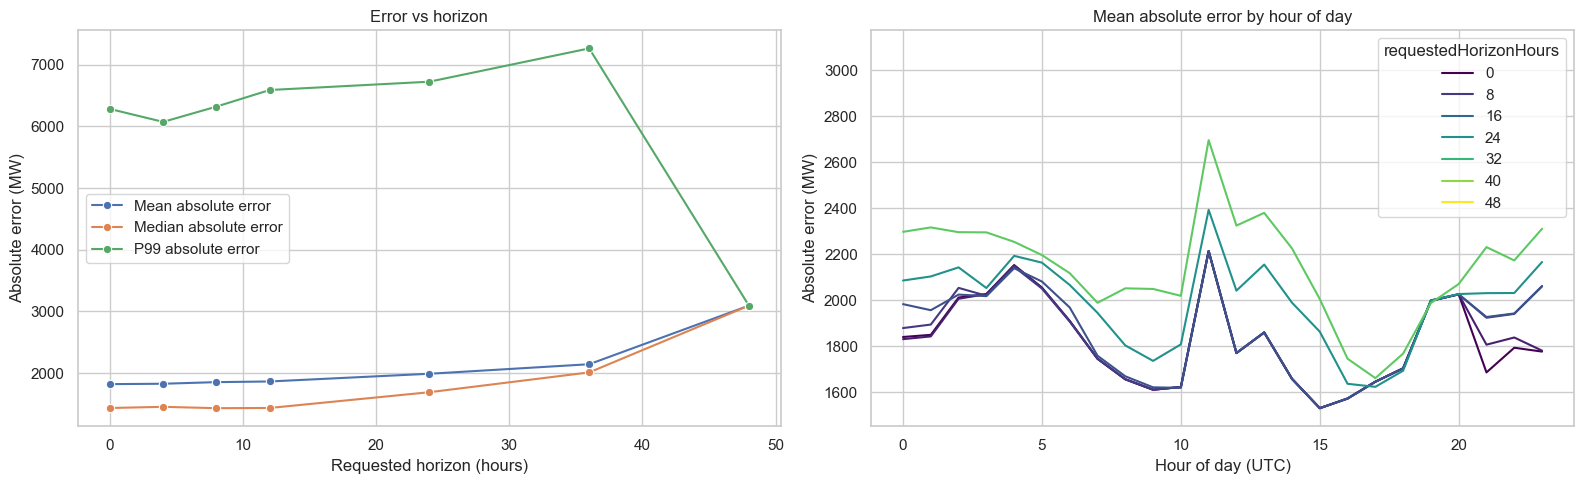

,requestedHorizonHours,mean,median,p99,count
0,0,"1,822","1,434","6,282",744
1,4,"1,828","1,454","6,073",744
2,8,"1,854","1,432","6,321",744
3,12,"1,865","1,435","6,590",744
4,24,"1,990","1,690","6,724",744
5,36,"2,144","2,012","7,264",744
6,48,"3,094","3,094","3,094",1


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(data=summary, x='requestedHorizonHours', y='mean', marker='o', ax=axes[0], label='Mean absolute error')
sns.lineplot(data=summary, x='requestedHorizonHours', y='median', marker='o', ax=axes[0], label='Median absolute error')
sns.lineplot(data=summary, x='requestedHorizonHours', y='p99', marker='o', ax=axes[0], label='P99 absolute error')
axes[0].set_title('Error vs horizon')
axes[0].set_xlabel('Requested horizon (hours)')
axes[0].set_ylabel('Absolute error (MW)')

tod = error_rows.groupby(['requestedHorizonHours', 'hourOfDay'])['absoluteError'].mean().reset_index()
sns.lineplot(data=tod, x='hourOfDay', y='absoluteError', hue='requestedHorizonHours', palette='viridis', ax=axes[1])
axes[1].set_title('Mean absolute error by hour of day')
axes[1].set_xlabel('Hour of day (UTC)')
axes[1].set_ylabel('Absolute error (MW)')

plt.tight_layout()
plt.show()

summary.style.format({'mean': '{:,.0f}', 'median': '{:,.0f}', 'p99': '{:,.0f}'})
